# Set Prediction Loss Gradient Analysis

This notebook investigates **why the softmin-based losses underperform Chamfer and Hungarian** on the CLEVR DSPN benchmark despite working well on earlier toy experiments.

**Hypothesis:** The temperature `tau=0.5` (chosen to match L2 distance scale) produces an almost-uniform softmax distribution over the 10 targets, causing all prediction slots to receive nearly identical gradient signals. This is the centroid collapse trap.

**Structure:**
1. Toy example: visualise what the losses do geometrically
2. The softmax distribution: show how tau controls matching sharpness
3. Gradient analysis: compare gradient fields for each loss at tau=0.5 vs tau=0.1
4. The centroid collapse: prove that high tau leads to a fixed-point attractor
5. Recovery: show that tau=0.1 escapes the trap
6. Sanity check against the MLP toy benchmark results

In [15]:
import sys
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.optimize import linear_sum_assignment

sys.path.insert(0, '..')
from influencerformer.losses import (
    ChamferLoss, HungarianLoss,
    PowerSoftMinLoss, ProductWeightedSoftMinLoss, SoftMinChamferLoss,
)

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Toy Setup: 2D Point Sets

We use **2D points** so we can visualise everything. A single "scene" with N=5 target points, and M=5 predicted points starting near the centroid (simulating the collapsed state we see in training).

Centroid: tensor([0.1000, 0.1000])


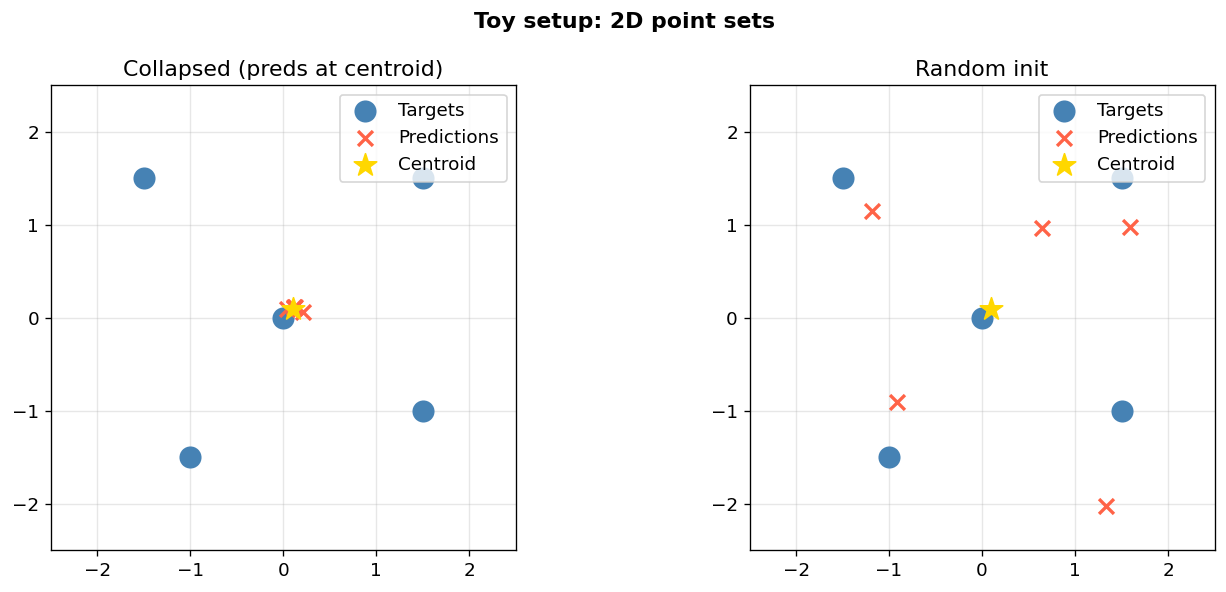

In [3]:
def pairwise_l2(preds, targets):
    """(M, D), (N, D) -> (1, M, N) distance matrix."""
    return torch.cdist(preds.unsqueeze(0), targets.unsqueeze(0))  # (1, M, N)


# Fixed targets: 5 distinct 2D points
targets_2d = torch.tensor([
    [-1.5,  1.5],
    [ 1.5,  1.5],
    [ 0.0,  0.0],
    [-1.0, -1.5],
    [ 1.5, -1.0],
], dtype=torch.float32)

centroid = targets_2d.mean(dim=0)
print(f"Centroid: {centroid}")

# Predictions: 5 points slightly scattered near the centroid (collapsed state)
preds_collapsed = centroid.unsqueeze(0).expand(5, -1) + 0.05 * torch.randn(5, 2)

# Predictions: 5 points spread out but wrong (initial random state)
preds_random = torch.randn(5, 2) * 1.2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(axes, [preds_collapsed, preds_random],
                             ['Collapsed (preds at centroid)', 'Random init']):
    ax.scatter(*targets_2d.T.numpy(), s=150, c='steelblue', zorder=5, label='Targets')
    ax.scatter(*preds.T.detach().numpy(), s=80, c='tomato', marker='x', zorder=5,
               linewidths=2, label='Predictions')
    ax.scatter(*centroid.numpy(), s=200, c='gold', marker='*', zorder=6, label='Centroid')
    ax.set_title(title)
    ax.legend(loc='upper right')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

plt.suptitle('Toy setup: 2D point sets', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. The Softmax Distribution: How tau Controls Matching Sharpness

For each **target** j, softmin looks at all M prediction distances `{D_1j, ..., D_Mj}` and weights them via `softmax(-D/tau, dim=preds)`. A perfect loss wants ALL weight on the nearest prediction. Let's see what actually happens.

Distance matrix (collapsed preds):
[[2.135 1.963 0.158 1.957 1.771]
 [2.127 1.963 0.158 1.958 1.778]
 [2.09  2.026 0.101 1.903 1.819]
 [2.231 1.927 0.221 1.981 1.674]
 [2.135 1.954 0.167 1.966 1.771]]

Min D: 0.101, Max D: 2.231
Mean D: 1.597


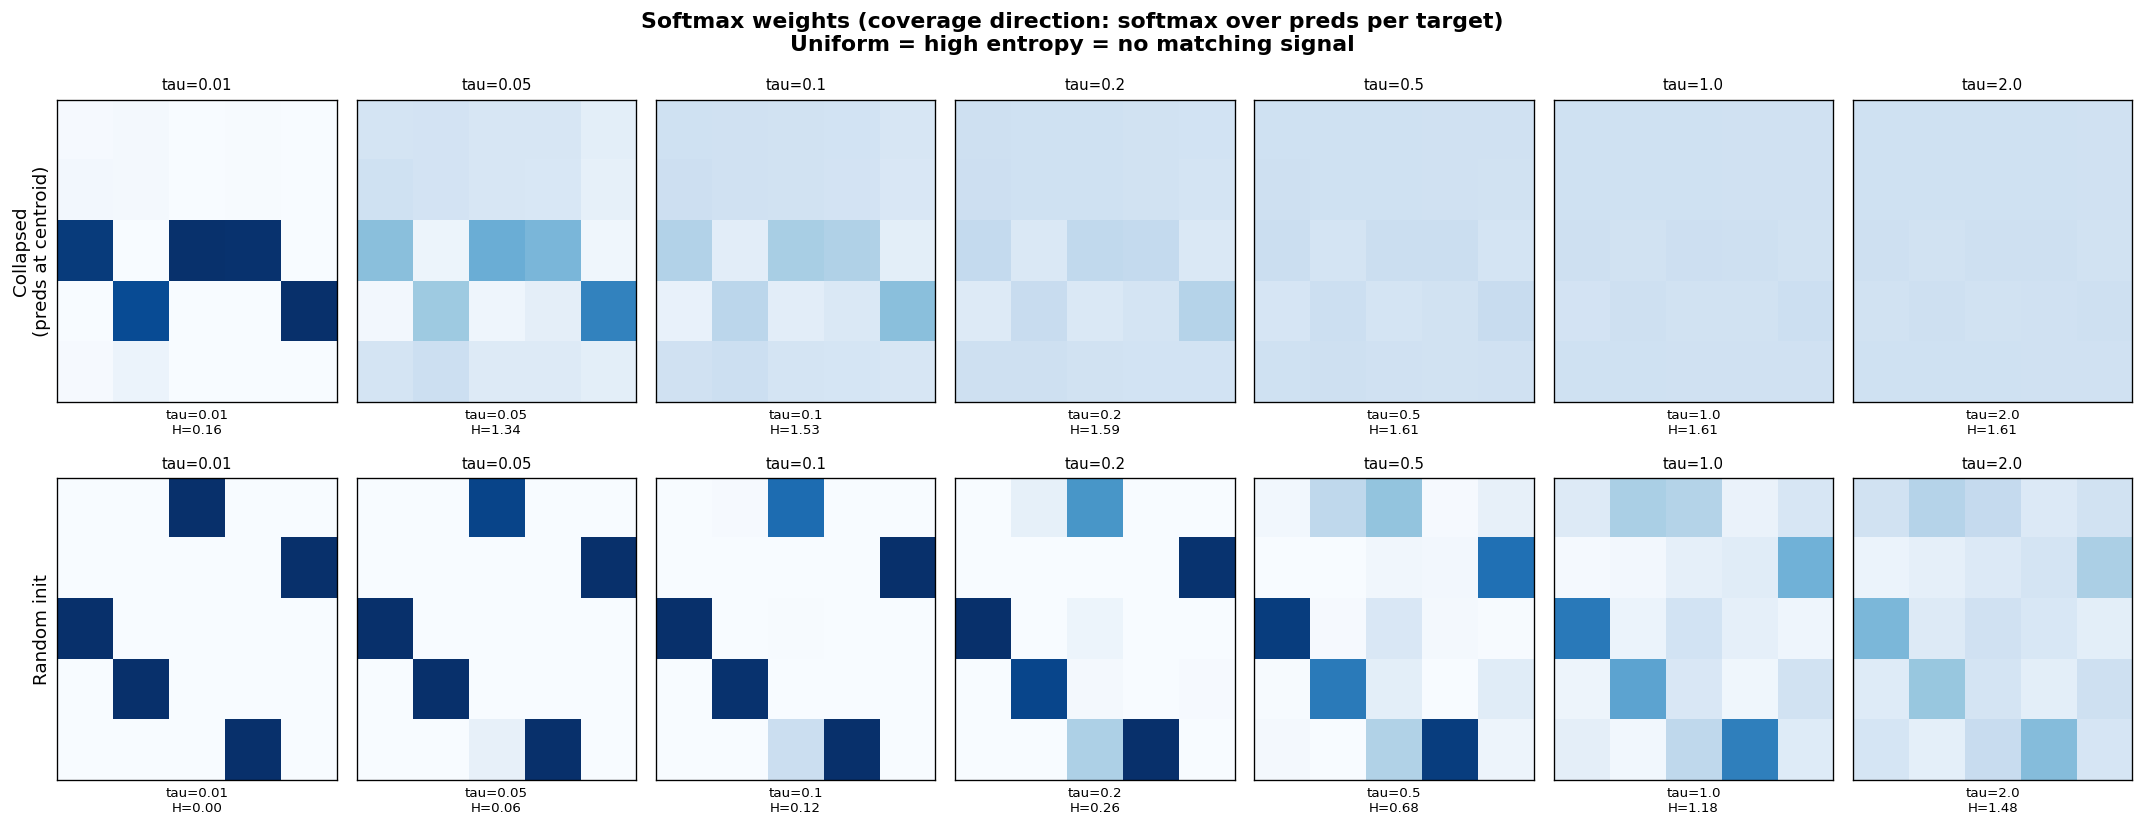


Max/mean weight ratio (1.0 = uniform, high = sharp)
tau         collapsed       random
0.01             4.83         5.00
0.05             2.44         4.92
0.10             1.68         4.76
0.20             1.32         4.51
0.50             1.12         3.76
1.00             1.06         2.74
2.00             1.03         1.87


In [4]:
taus = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]

# Use the collapsed preds case
D_collapsed = pairwise_l2(preds_collapsed, targets_2d)  # (1, 5, 5)
D_random = pairwise_l2(preds_random, targets_2d)  # (1, 5, 5)

print("Distance matrix (collapsed preds):")
print(D_collapsed[0].numpy().round(3))
print(f"\nMin D: {D_collapsed.min():.3f}, Max D: {D_collapsed.max():.3f}")
print(f"Mean D: {D_collapsed.mean():.3f}")

fig, axes = plt.subplots(2, len(taus), figsize=(18, 7))

for col, tau in enumerate(taus):
    for row, (D, label) in enumerate([(D_collapsed, 'Collapsed'), (D_random, 'Random')]):
        ax = axes[row, col]
        weights = torch.softmax(-D[0] / tau, dim=0).numpy()  # (M, N): weight per pred per target
        im = ax.imshow(weights, vmin=0, vmax=1, cmap='Blues', aspect='auto')
        ax.set_title(f'tau={tau}', fontsize=9)
        if col == 0:
            ax.set_ylabel(label)
            ax.set_xlabel('Target j')
        ax.set_xticks([])
        ax.set_yticks([])
        # Add entropy as subtitle
        entropy = -(weights * np.log(weights + 1e-10)).sum(axis=0).mean()
        ax.set_xlabel(f'tau={tau}\nH={entropy:.2f}', fontsize=8)

axes[0, 0].set_ylabel('Collapsed\n(preds at centroid)')
axes[1, 0].set_ylabel('Random init')
plt.suptitle('Softmax weights (coverage direction: softmax over preds per target)\n'
             'Uniform = high entropy = no matching signal', fontweight='bold')
plt.tight_layout()
plt.show()

# Also: quantify the max/mean weight ratio
print("\nMax/mean weight ratio (1.0 = uniform, high = sharp)")
print(f"{'tau':<8} {'collapsed':>12} {'random':>12}")
N = 5
uniform = 1.0 / N
for tau in taus:
    wc = torch.softmax(-D_collapsed[0] / tau, dim=0)
    wr = torch.softmax(-D_random[0] / tau, dim=0)
    rc = (wc.max(dim=0).values / uniform).mean().item()
    rr = (wr.max(dim=0).values / uniform).mean().item()
    print(f"{tau:<8.2f} {rc:>12.2f} {rr:>12.2f}")

## 3. Gradient Analysis: The Key Experiment

We compute **analytical gradients** of each loss with respect to each prediction point in the collapsed configuration. If the gradient is uniform across all predictions, the model cannot know which prediction to move where — this is the centroid collapse trap.

We compute `d(loss)/d(pred_i)` for i=0..4 and visualise as arrows on the 2D plane.

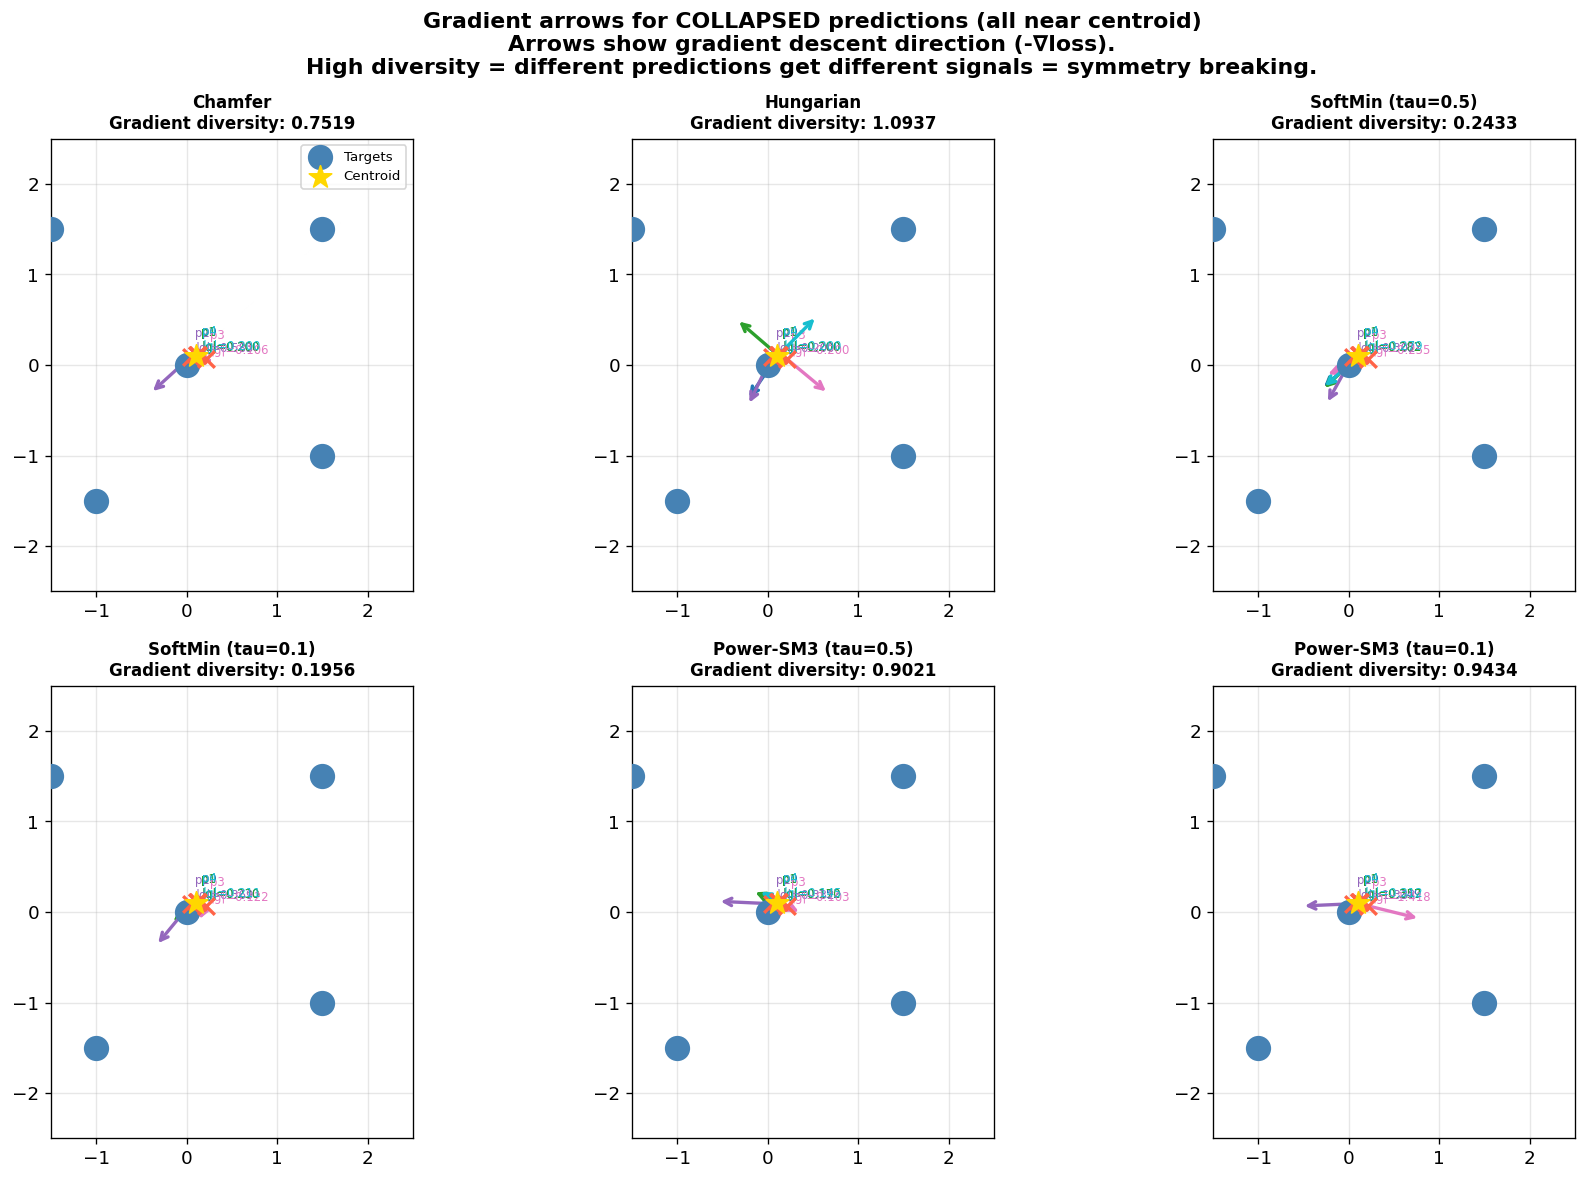

In [5]:
def compute_gradients(preds, targets, loss_fn, requires_grad=True):
    """Compute gradient of loss w.r.t. predictions."""
    p = preds.clone().requires_grad_(True)
    D = pairwise_l2(p, targets)
    loss = loss_fn(D)
    loss.backward()
    return p.grad.clone()


losses_to_test = {
    'Chamfer': ChamferLoss(),
    'Hungarian': HungarianLoss(),
    'SoftMin (tau=0.5)': SoftMinChamferLoss(temperature=0.5),
    'SoftMin (tau=0.1)': SoftMinChamferLoss(temperature=0.1),
    'Power-SM3 (tau=0.5)': PowerSoftMinLoss(temperature=0.5, power=3.0),
    'Power-SM3 (tau=0.1)': PowerSoftMinLoss(temperature=0.1, power=3.0),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Use collapsed preds
colors = plt.cm.tab10(np.linspace(0, 0.9, 5))

for ax, (name, loss_fn) in zip(axes, losses_to_test.items()):
    grads = compute_gradients(preds_collapsed, targets_2d, loss_fn)
    
    # Normalize for display, but also compute magnitude
    magnitudes = grads.norm(dim=1)
    
    ax.scatter(*targets_2d.T.numpy(), s=200, c='steelblue', zorder=5, label='Targets')
    ax.scatter(*centroid.numpy(), s=200, c='gold', marker='*', zorder=6, label='Centroid')
    ax.scatter(*preds_collapsed.T.detach().numpy(), s=100, c='tomato', marker='x',
               linewidths=2, zorder=5)

    # Draw gradients as arrows (negated, since we descend)
    max_mag = magnitudes.max().item()
    for i, (p, g, m) in enumerate(zip(preds_collapsed, grads, magnitudes)):
        scale = 0.6 / max(max_mag, 1e-8)
        ax.annotate('', xy=p.numpy() - g.numpy() * scale,
                    xytext=p.numpy(),
                    arrowprops=dict(arrowstyle='->', color=colors[i], lw=2))
        ax.text(p[0].item() + 0.05, p[1].item() + 0.05, f'p{i}\n|g|={m:.3f}',
                fontsize=7, color=colors[i])

    # Gradient diversity: std of gradient directions (higher = more useful signal)
    g_norm = F.normalize(grads, dim=1)  # unit vectors
    angular_std = g_norm.std(dim=0).norm().item()
    
    ax.set_title(f'{name}\nGradient diversity: {angular_std:.4f}', fontweight='bold', fontsize=10)
    ax.set_xlim(-1.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    if ax == axes[0]:
        ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Gradient arrows for COLLAPSED predictions (all near centroid)\n'
             'Arrows show gradient descent direction (-∇loss).\n'
             'High diversity = different predictions get different signals = symmetry breaking.',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 4. The Centroid Collapse: Mathematical Proof

We prove that the centroid IS a fixed point for SoftMin with high tau, but NOT for Chamfer or low-tau SoftMin.

**Definition:** A point configuration is a fixed point if `∇loss = 0` for all predictions, OR if all gradients point identically (so gradient descent doesn't break symmetry).

In [6]:
# At the EXACT centroid, are the gradients all identical?
# If gradient[pred_i] == gradient[pred_j] for all i, j, the model cannot break symmetry.

preds_exact_centroid = centroid.unsqueeze(0).expand(5, -1).clone()
# Add tiny perturbation to avoid exact degeneracy
preds_near_centroid = preds_exact_centroid + 1e-4 * torch.randn(5, 2)

print("=" * 70)
print("GRADIENT ANALYSIS AT (NEAR) CENTROID")
print("=" * 70)
print()

configs = [
    (1e-4, "epsilon=1e-4 (near centroid)"),
    (0.01, "epsilon=0.01"),
    (0.1, "epsilon=0.1"),
]

test_losses = {
    'Chamfer': ChamferLoss(),
    'SoftMin tau=0.5': SoftMinChamferLoss(temperature=0.5),
    'SoftMin tau=0.1': SoftMinChamferLoss(temperature=0.1),
    'Power-SM3 tau=0.5': PowerSoftMinLoss(temperature=0.5, power=3.0),
    'Power-SM3 tau=0.1': PowerSoftMinLoss(temperature=0.1, power=3.0),
}

for epsilon, label in configs:
    print(f"\n--- {label} ---")
    preds = centroid.unsqueeze(0).expand(5, -1).clone()
    preds = preds + epsilon * torch.randn(5, 2)
    
    for name, loss_fn in test_losses.items():
        grads = compute_gradients(preds, targets_2d, loss_fn)
        # Measure gradient similarity: if all gradients are the same, std ~ 0
        grad_std = grads.std(dim=0)  # std across the 5 predictions
        grad_mean_norm = grads.norm(dim=1).mean().item()
        similarity = grads.std(dim=0).norm().item() / (grads.mean(dim=0).norm().item() + 1e-10)
        print(f"  {name:<25}  grad_diversity={similarity:.4f}  (0=all same, high=varied)")

GRADIENT ANALYSIS AT (NEAR) CENTROID


--- epsilon=1e-4 (near centroid) ---
  Chamfer                    grad_diversity=1.0975  (0=all same, high=varied)
  SoftMin tau=0.5            grad_diversity=0.0003  (0=all same, high=varied)
  SoftMin tau=0.1            grad_diversity=0.0008  (0=all same, high=varied)
  Power-SM3 tau=0.5          grad_diversity=0.0027  (0=all same, high=varied)
  Power-SM3 tau=0.1          grad_diversity=0.0202  (0=all same, high=varied)

--- epsilon=0.01 ---
  Chamfer                    grad_diversity=1.0922  (0=all same, high=varied)
  SoftMin tau=0.5            grad_diversity=0.0542  (0=all same, high=varied)
  SoftMin tau=0.1            grad_diversity=0.0913  (0=all same, high=varied)
  Power-SM3 tau=0.5          grad_diversity=0.3496  (0=all same, high=varied)
  Power-SM3 tau=0.1          grad_diversity=2.6048  (0=all same, high=varied)

--- epsilon=0.1 ---
  Chamfer                    grad_diversity=1.0026  (0=all same, high=varied)
  SoftMin tau=0.5      

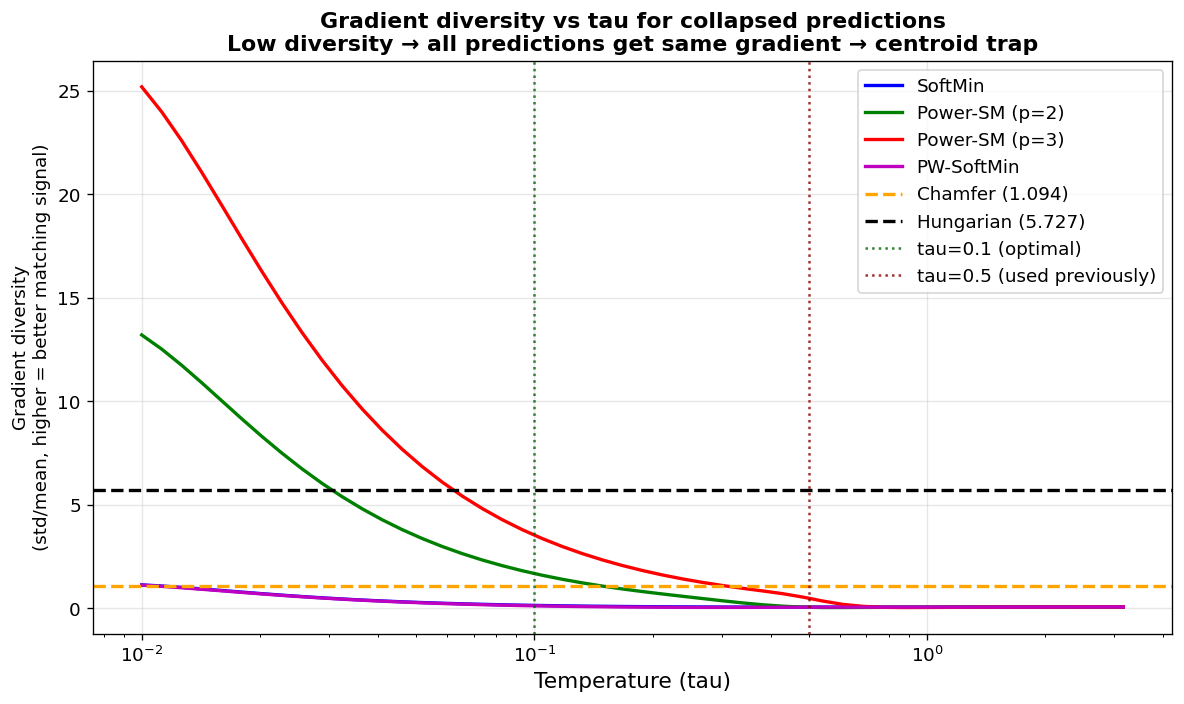

SoftMin: diversity at tau=0.1: 0.1377, at tau=0.5: 0.0550, ratio: 2.5x
Power-SM3: diversity at tau=0.1: 3.5431, at tau=0.5: 0.4839, ratio: 7.3x


In [7]:
# Sweep tau to show gradient diversity as a function of tau

taus_sweep = np.logspace(-2, 0.5, 50)  # 0.01 to ~3.2
epsilon = 0.01  # small perturbation from centroid

diversity_softmin = []
diversity_power2 = []
diversity_power3 = []
diversity_pwsm = []

preds_near = centroid.unsqueeze(0).expand(5, -1).clone() + epsilon * torch.randn(5, 2)

for tau in taus_sweep:
    tau = float(tau)
    for div_list, loss_fn in [
        (diversity_softmin, SoftMinChamferLoss(temperature=tau)),
        (diversity_power2, PowerSoftMinLoss(temperature=tau, power=2.0)),
        (diversity_power3, PowerSoftMinLoss(temperature=tau, power=3.0)),
        (diversity_pwsm, ProductWeightedSoftMinLoss(temperature=tau)),
    ]:
        grads = compute_gradients(preds_near, targets_2d, loss_fn)
        similarity = grads.std(dim=0).norm().item() / (grads.mean(dim=0).norm().item() + 1e-10)
        div_list.append(similarity)

# Chamfer and Hungarian as horizontal reference lines
chamfer_div = []
for _ in [0]:  # just once
    grads = compute_gradients(preds_near, targets_2d, ChamferLoss())
    chamfer_div = grads.std(dim=0).norm().item() / (grads.mean(dim=0).norm().item() + 1e-10)

hungarian_div = []
grads_hun = compute_gradients(preds_near, targets_2d, HungarianLoss())
hungarian_div = grads_hun.std(dim=0).norm().item() / (grads_hun.mean(dim=0).norm().item() + 1e-10)

fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogx(taus_sweep, diversity_softmin, 'b-', label='SoftMin', lw=2)
ax.semilogx(taus_sweep, diversity_power2, 'g-', label='Power-SM (p=2)', lw=2)
ax.semilogx(taus_sweep, diversity_power3, 'r-', label='Power-SM (p=3)', lw=2)
ax.semilogx(taus_sweep, diversity_pwsm, 'm-', label='PW-SoftMin', lw=2)
ax.axhline(chamfer_div, c='orange', ls='--', lw=2, label=f'Chamfer ({chamfer_div:.3f})')
ax.axhline(hungarian_div, c='black', ls='--', lw=2, label=f'Hungarian ({hungarian_div:.3f})')

# Mark our two tau choices
ax.axvline(0.1, c='darkgreen', ls=':', alpha=0.8, label='tau=0.1 (optimal)')
ax.axvline(0.5, c='darkred', ls=':', alpha=0.8, label='tau=0.5 (used previously)')

ax.set_xlabel('Temperature (tau)', fontsize=13)
ax.set_ylabel('Gradient diversity\n(std/mean, higher = better matching signal)', fontsize=11)
ax.set_title('Gradient diversity vs tau for collapsed predictions\n'
             'Low diversity → all predictions get same gradient → centroid trap',
             fontweight='bold')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print key values
for name, divs in [('SoftMin', diversity_softmin), ('Power-SM3', diversity_power3)]:
    div_01 = np.interp(0.1, taus_sweep, divs)
    div_05 = np.interp(0.5, taus_sweep, divs)
    print(f"{name}: diversity at tau=0.1: {div_01:.4f}, at tau=0.5: {div_05:.4f}, ratio: {div_01/div_05:.1f}x")

## 5. Simulate Gradient Descent: Does it Escape the Centroid?

We simulate 500 steps of gradient descent from the collapsed initialization for each loss/tau combination and track whether predictions escape the centroid.

Running Chamfer...
Running Hungarian...
Running SoftMin tau=0.5...
Running SoftMin tau=0.1...
Running Power-SM3 tau=0.5...
Running Power-SM3 tau=0.1...
Running PW-SoftMin tau=0.5...
Running PW-SoftMin tau=0.1...


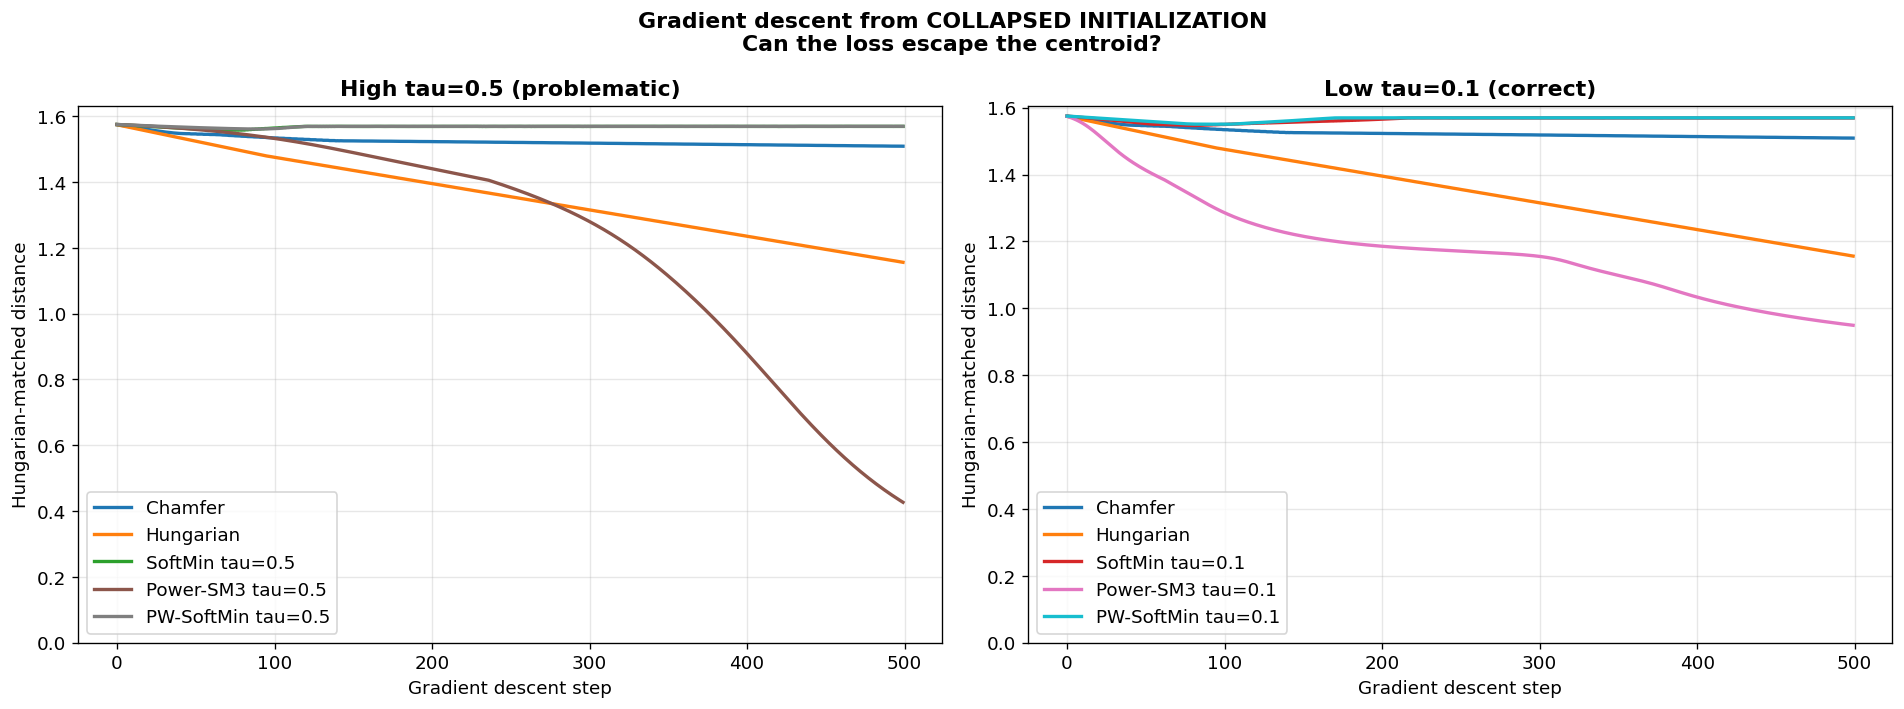


Final Hungarian-matched distances after 500 steps:
Name                             Final dist   Escaped?
-------------------------------------------------------
Power-SM3 tau=0.5                    0.4267        YES
Power-SM3 tau=0.1                    0.9492         NO
Hungarian                            1.1562         NO
Chamfer                              1.5090         NO
SoftMin tau=0.5                      1.5692         NO
SoftMin tau=0.1                      1.5693         NO
PW-SoftMin tau=0.5                   1.5695         NO
PW-SoftMin tau=0.1                   1.5697         NO


In [8]:
def simulate_gradient_descent(preds_init, targets, loss_fn, n_steps=500, lr=0.01):
    """Run gradient descent and track matched distance over steps."""
    preds = preds_init.clone()
    history = []

    for step in range(n_steps):
        preds = preds.clone().requires_grad_(True)
        D = pairwise_l2(preds, targets)
        loss = loss_fn(D)
        loss.backward()
        with torch.no_grad():
            preds = preds - lr * preds.grad

        # Compute matched distance via Hungarian on this step
        with torch.no_grad():
            D_np = pairwise_l2(preds, targets)[0].numpy()
            row, col = linear_sum_assignment(D_np)
            matched_dist = D_np[row, col].mean()
        history.append(matched_dist)

    return preds.detach(), history


# Initial collapsed predictions (same for all)
preds_init = centroid.unsqueeze(0).expand(5, -1).clone() + 0.02 * torch.randn(5, 2)

configs = [
    ('Chamfer', ChamferLoss()),
    ('Hungarian', HungarianLoss()),
    ('SoftMin tau=0.5', SoftMinChamferLoss(temperature=0.5)),
    ('SoftMin tau=0.1', SoftMinChamferLoss(temperature=0.1)),
    ('Power-SM3 tau=0.5', PowerSoftMinLoss(temperature=0.5, power=3.0)),
    ('Power-SM3 tau=0.1', PowerSoftMinLoss(temperature=0.1, power=3.0)),
    ('PW-SoftMin tau=0.5', ProductWeightedSoftMinLoss(temperature=0.5)),
    ('PW-SoftMin tau=0.1', ProductWeightedSoftMinLoss(temperature=0.1)),
]

results = {}
for name, loss_fn in configs:
    print(f"Running {name}...")
    final_preds, history = simulate_gradient_descent(
        preds_init, targets_2d, loss_fn, n_steps=500, lr=0.005
    )
    results[name] = (final_preds, history)

# Plot convergence curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_map = plt.cm.tab10(np.linspace(0, 0.9, len(configs)))

for ax, tau_filter, title in zip(
    axes,
    [['tau=0.5', 'Chamfer', 'Hungarian'], ['tau=0.1', 'Chamfer', 'Hungarian']],
    ['High tau=0.5 (problematic)', 'Low tau=0.1 (correct)']
):
    for i, (name, (_, history)) in enumerate(results.items()):
        if any(f in name for f in tau_filter):
            ax.plot(history, label=name, color=colors_map[i], lw=2)
    ax.set_xlabel('Gradient descent step')
    ax.set_ylabel('Hungarian-matched distance')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0, None)

plt.suptitle('Gradient descent from COLLAPSED INITIALIZATION\n'
             'Can the loss escape the centroid?', fontweight='bold')
plt.tight_layout()
plt.show()

# Print final distances
print("\nFinal Hungarian-matched distances after 500 steps:")
print(f"{'Name':<30} {'Final dist':>12} {'Escaped?':>10}")
print("-" * 55)
for name, (_, history) in sorted(results.items(), key=lambda x: x[1][1][-1]):
    final = history[-1]
    escaped = "YES" if final < 0.5 else "NO"
    print(f"{name:<30} {final:>12.4f} {escaped:>10}")

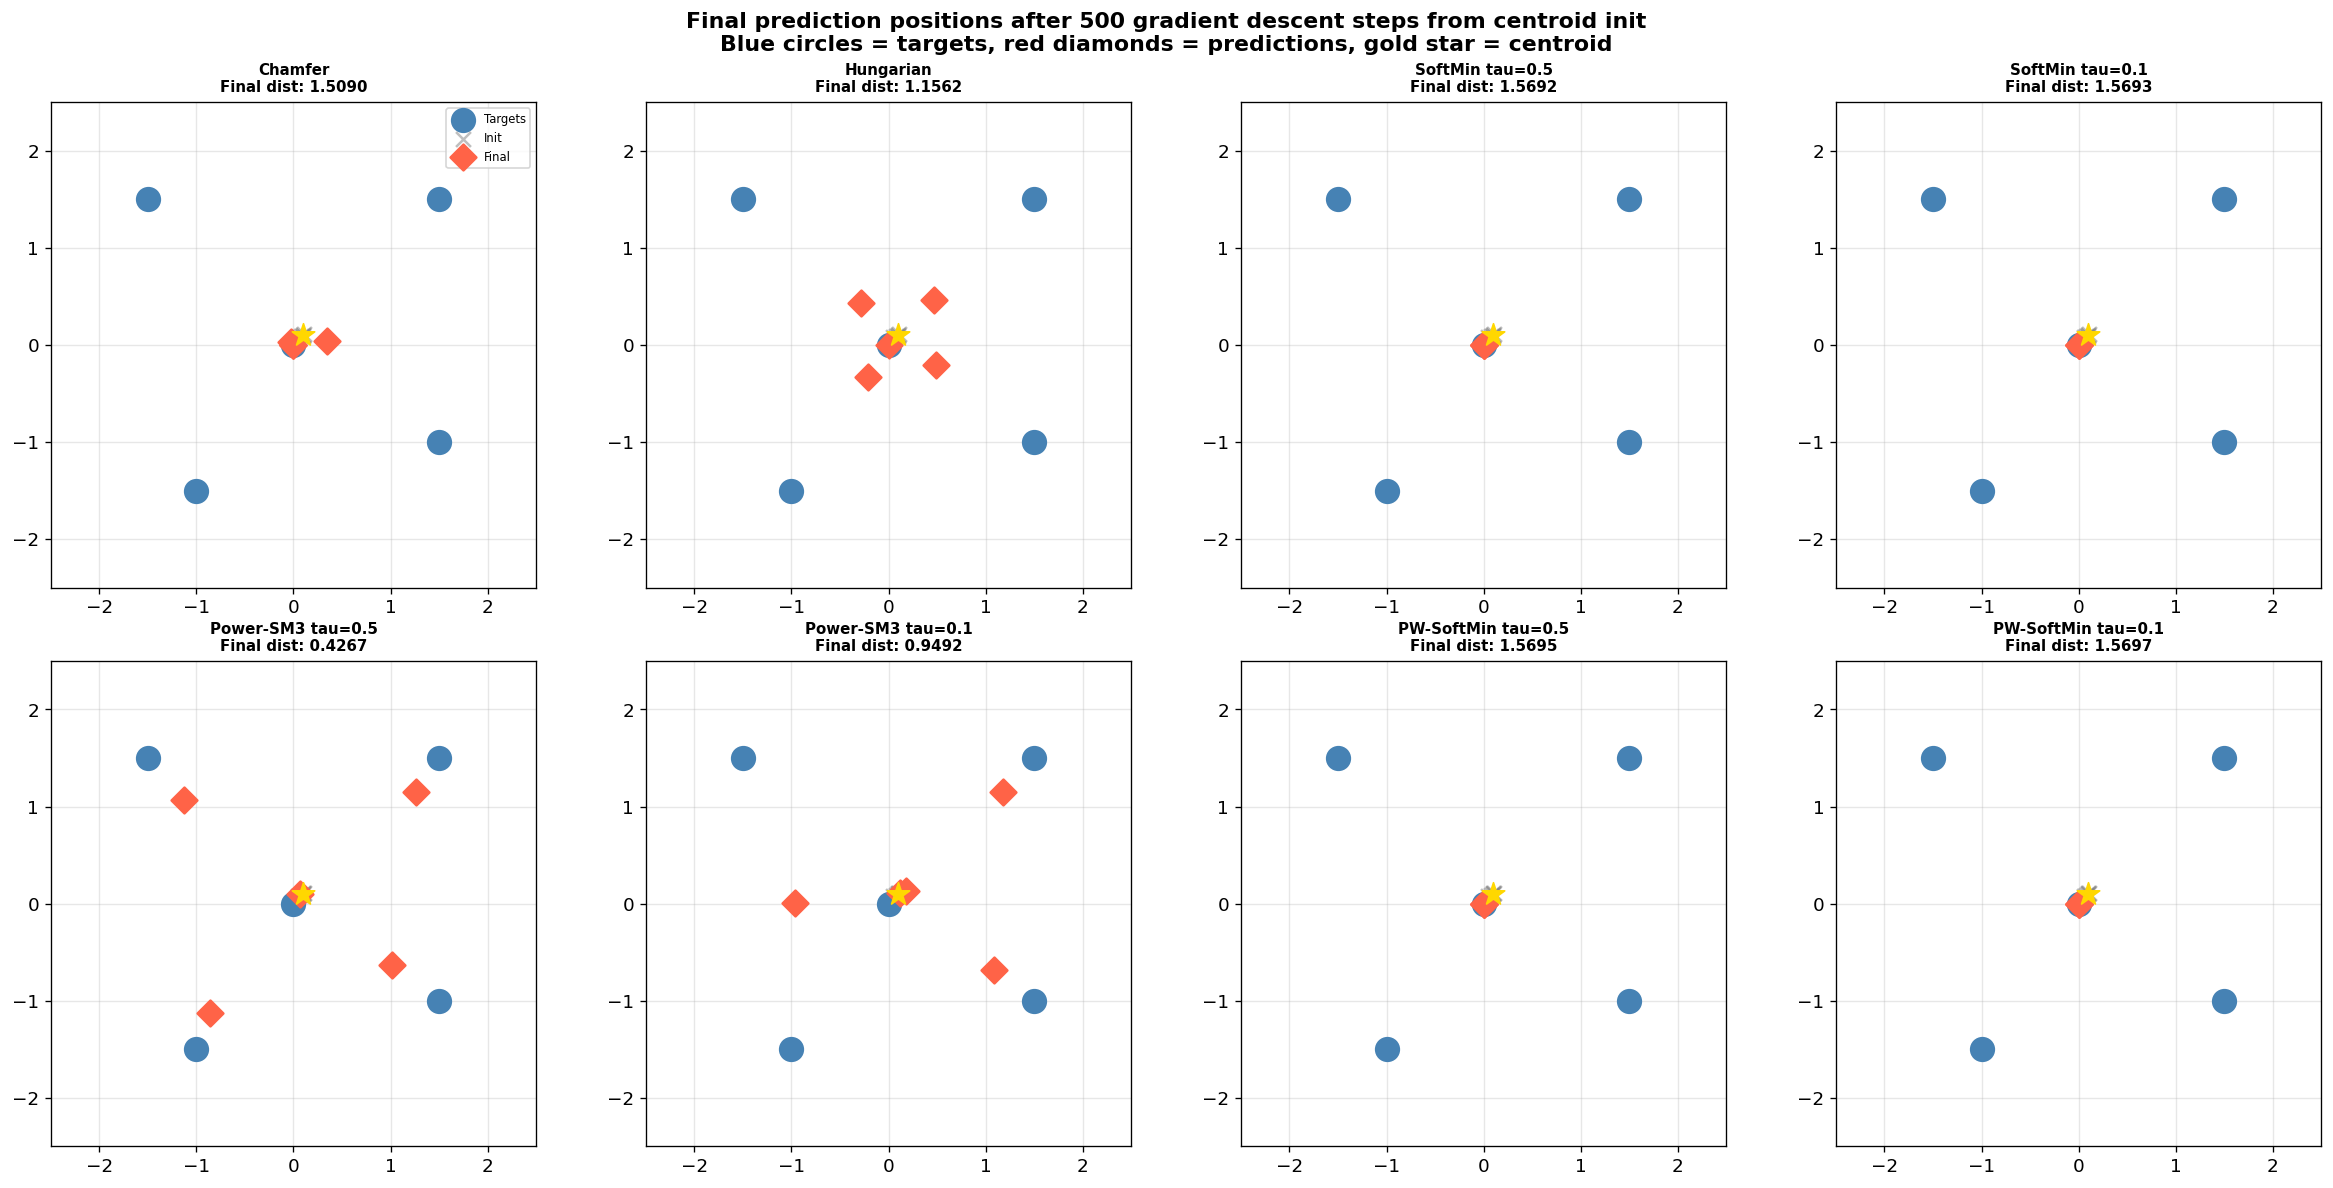

In [9]:
# Visualise final prediction positions for each method

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (name, (final_preds, history)) in zip(axes, results.items()):
    ax.scatter(*targets_2d.T.numpy(), s=200, c='steelblue', zorder=5, label='Targets')
    ax.scatter(*preds_init.T.detach().numpy(), s=80, c='gray', marker='x',
               linewidths=1.5, zorder=4, label='Init', alpha=0.5)
    ax.scatter(*final_preds.T.numpy(), s=120, c='tomato', marker='D',
               linewidths=1.5, zorder=5, label='Final')
    ax.scatter(*centroid.numpy(), s=200, c='gold', marker='*', zorder=6)

    final_dist = history[-1]
    ax.set_title(f'{name}\nFinal dist: {final_dist:.4f}', fontsize=9, fontweight='bold')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper right', fontsize=7)
plt.suptitle('Final prediction positions after 500 gradient descent steps from centroid init\n'
             'Blue circles = targets, red diamonds = predictions, gold star = centroid',
             fontweight='bold')
plt.tight_layout()
plt.show()

## NEW: Training Trajectories from Random Initialisation

The previous experiment started from near the *collapsed* state. The more important question is:

**Given random initialisation, does each loss converge, collapse, or stay random?**

We run gradient descent from the same random initialisation for each loss and snapshot predictions at steps 0, 5, 20, 100, 500 so we can see *when* collapse or convergence happens — or doesn't.

In [16]:
def run_trajectory(preds_init, targets, loss_fn, n_steps=500, lr=0.005, snapshot_steps=None):
    """Run gradient descent and record prediction positions at each snapshot step.

    Returns list of (step, preds) tuples and the matched-distance history.
    """
    if snapshot_steps is None:
        snapshot_steps = [0, 5, 20, 100, 300, 500]

    preds = preds_init.clone()
    snapshots = []
    history = []

    for step in range(n_steps + 1):
        if step in snapshot_steps:
            snapshots.append((step, preds.detach().clone()))

        if step == n_steps:
            break

        preds = preds.clone().requires_grad_(True)
        D = pairwise_l2(preds, targets)
        loss = loss_fn(D)
        loss.backward()

        with torch.no_grad():
            preds = preds - lr * preds.grad

        with torch.no_grad():
            D_np = pairwise_l2(preds, targets)[0].numpy()
            row, col = linear_sum_assignment(D_np)
            history.append(D_np[row, col].mean())

    return snapshots, history


# Fixed random initialisation — same for all losses
torch.manual_seed(0)
preds_random_init = torch.randn(5, 2) * 1.5

configs_traj = [
    ('Chamfer',            ChamferLoss()),
    ('Hungarian',          HungarianLoss()),
    ('SoftMin τ=0.5',      SoftMinChamferLoss(temperature=0.5)),
    ('SoftMin τ=0.1',      SoftMinChamferLoss(temperature=0.1)),
    ('SoftMin τ=0.05',     SoftMinChamferLoss(temperature=0.05)),
    ('Power-SM3 τ=0.5',    PowerSoftMinLoss(temperature=0.5, power=3.0)),
    ('Power-SM3 τ=0.1',    PowerSoftMinLoss(temperature=0.1, power=3.0)),
    ('PW-SoftMin τ=0.1',   ProductWeightedSoftMinLoss(temperature=0.1)),
]

SNAPSHOT_STEPS = [0, 5, 20, 100, 300, 500]
N_STEPS = 500
LR = 0.005

trajectories = {}
for name, loss_fn in configs_traj:
    snaps, hist = run_trajectory(preds_random_init, targets_2d, loss_fn,
                                  n_steps=N_STEPS, lr=LR, snapshot_steps=SNAPSHOT_STEPS)
    trajectories[name] = (snaps, hist)
    final = hist[-1] if hist else float('nan')
    print(f'{name:<22}: final dist={final:.4f}')

Chamfer               : final dist=0.3959
Hungarian             : final dist=0.6799
SoftMin τ=0.5         : final dist=0.4117
SoftMin τ=0.1         : final dist=0.4011
SoftMin τ=0.05        : final dist=0.3953
Power-SM3 τ=0.5       : final dist=0.1397
Power-SM3 τ=0.1       : final dist=0.2698
PW-SoftMin τ=0.1      : final dist=0.3342


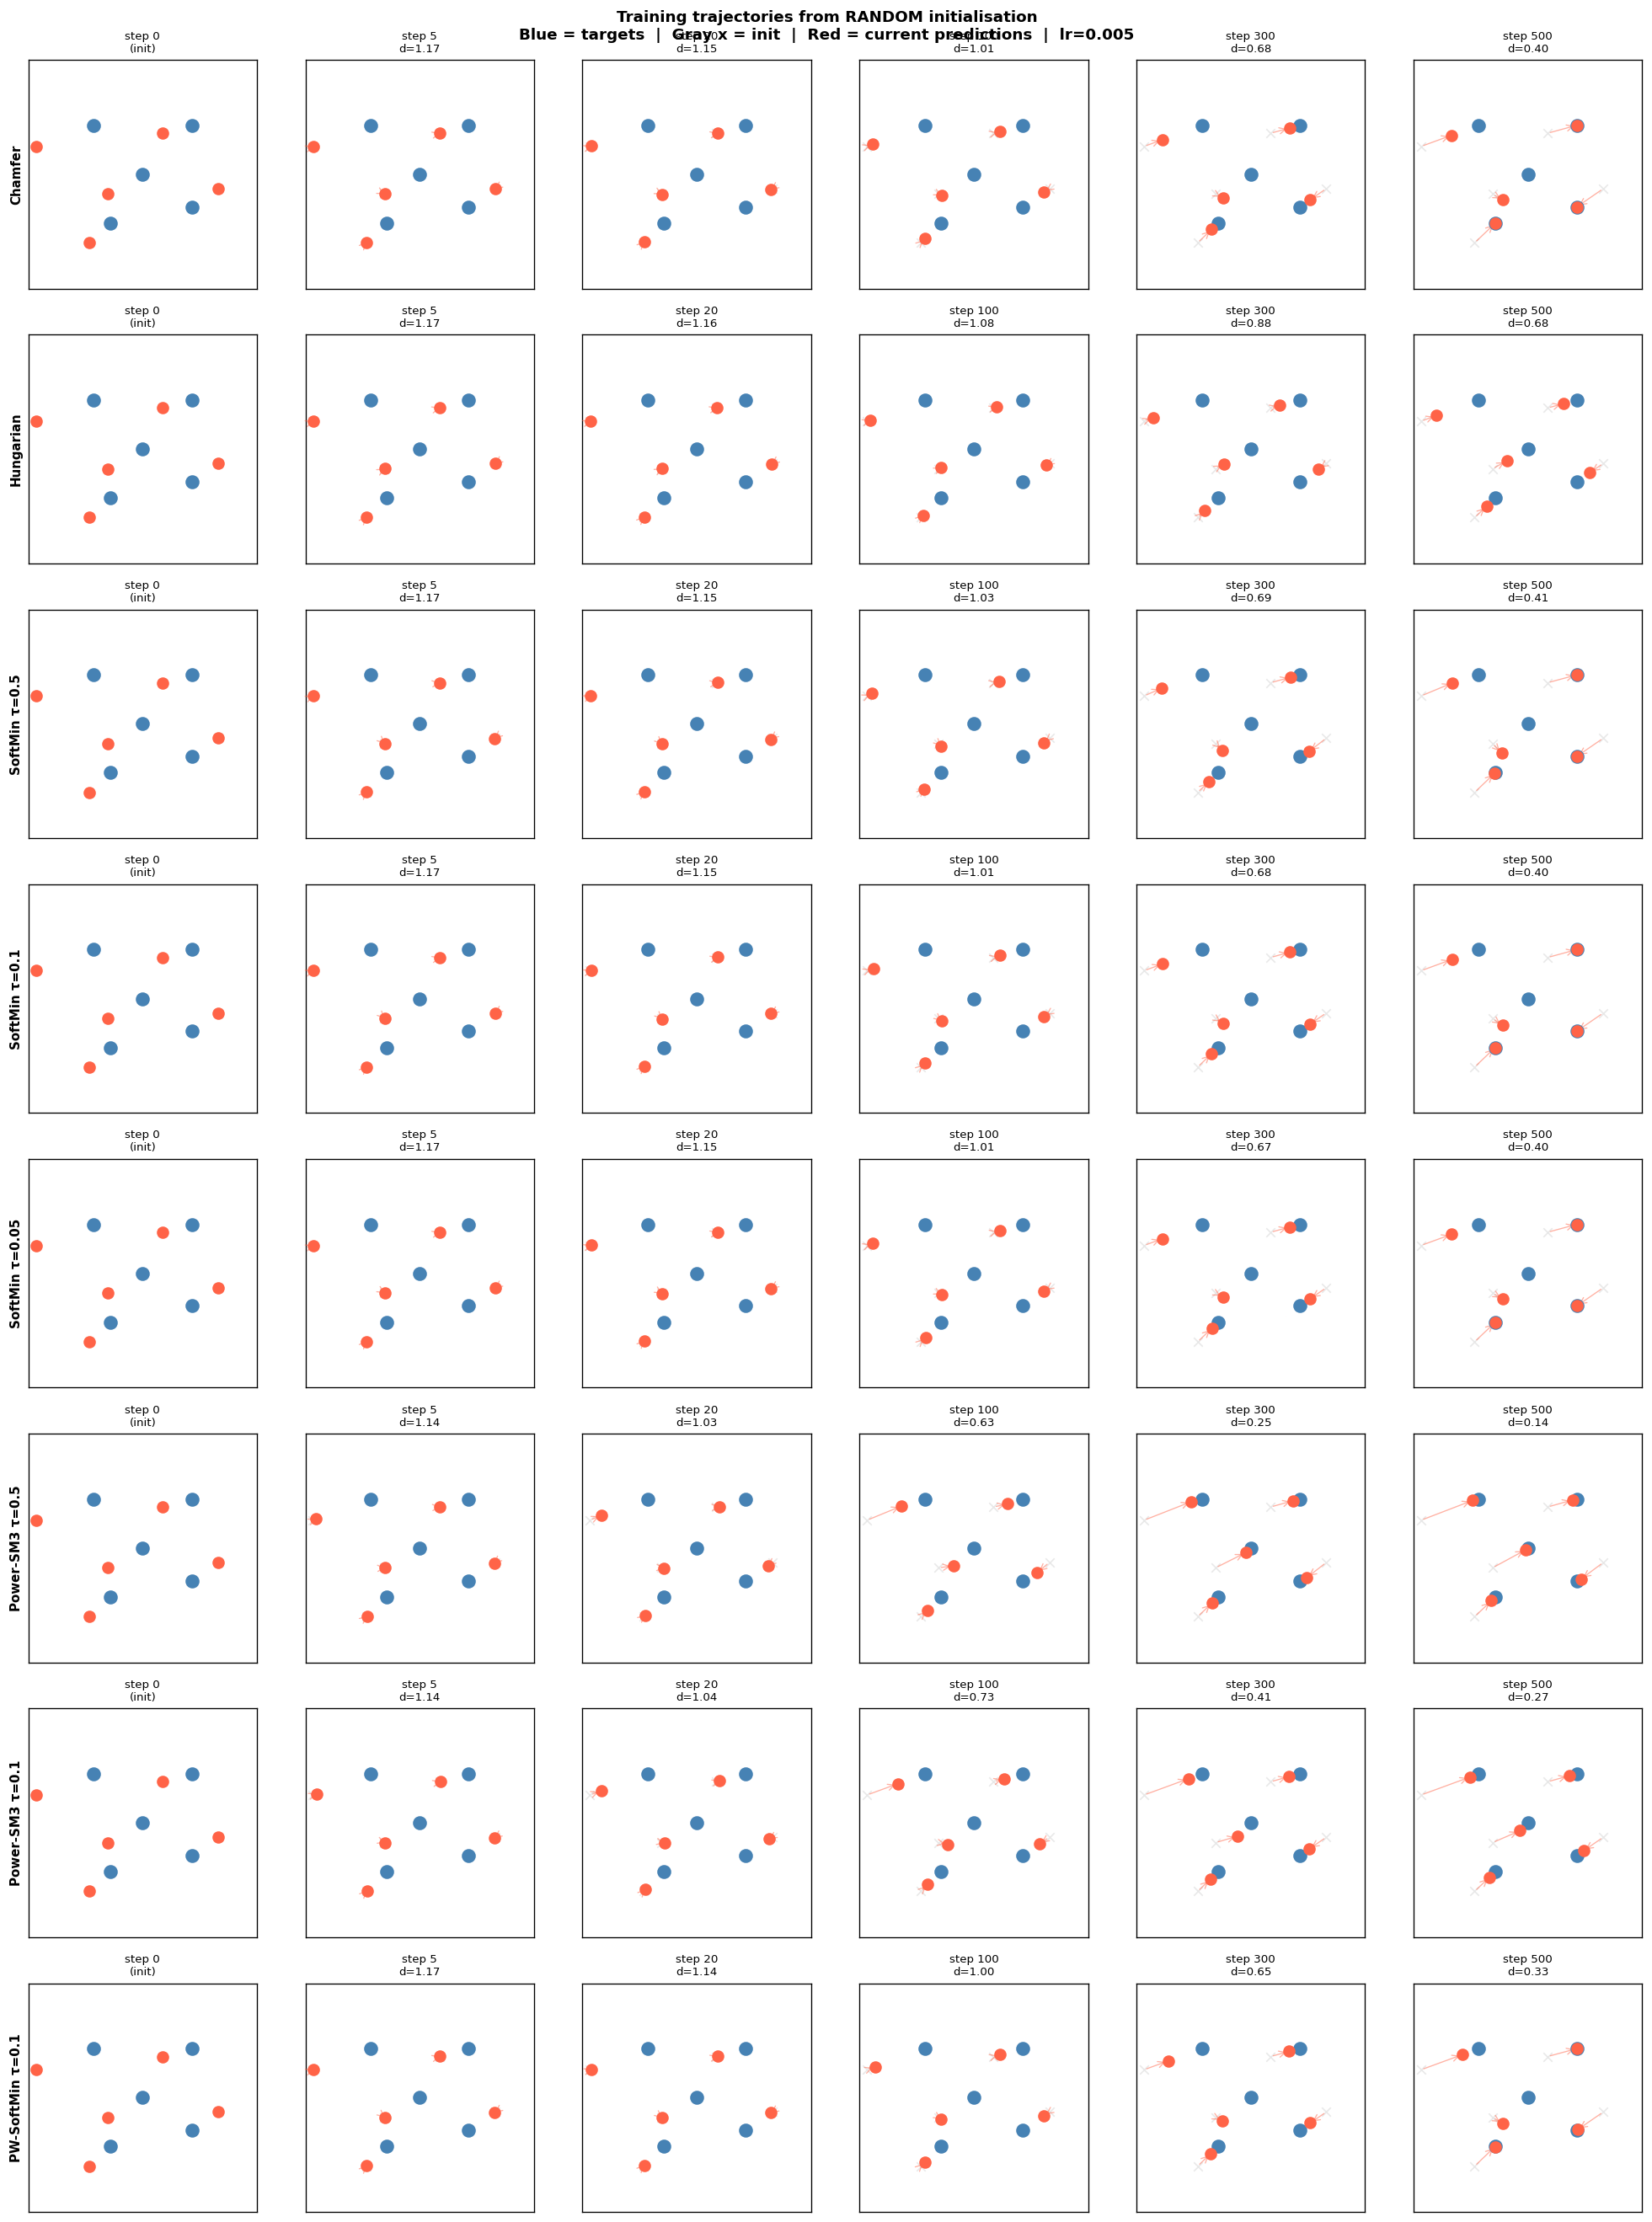

In [17]:
# --- Snapshot grid: rows = losses, cols = time steps ---
n_losses = len(configs_traj)
n_snaps = len(SNAPSHOT_STEPS)

fig, axes = plt.subplots(n_losses, n_snaps, figsize=(n_snaps * 2.8, n_losses * 2.8))

for row, (name, loss_fn) in enumerate(configs_traj):
    snaps, hist = trajectories[name]
    for col, (step, preds) in enumerate(snaps):
        ax = axes[row, col]

        ax.scatter(*targets_2d.T.numpy(), s=80, c='steelblue', zorder=5)
        ax.scatter(*preds_random_init.T.numpy(), s=40, c='lightgray',
                   marker='x', linewidths=1, zorder=3, alpha=0.5)
        ax.scatter(*preds.T.numpy(), s=60, c='tomato', zorder=5)

        # Draw movement arrows from init to current
        for p0, p1 in zip(preds_random_init.numpy(), preds.numpy()):
            ax.annotate('', xy=p1, xytext=p0,
                        arrowprops=dict(arrowstyle='->', color='tomato', lw=0.8, alpha=0.5))

        dist_now = hist[step - 1] if step > 0 else float('nan')
        ax.set_title(f'step {step}\nd={dist_now:.2f}' if step > 0 else f'step 0\n(init)',
                     fontsize=8)
        ax.set_xlim(-3.5, 3.5)
        ax.set_ylim(-3.5, 3.5)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(alpha=0.2)

        if col == 0:
            ax.set_ylabel(name, fontsize=9, fontweight='bold')

plt.suptitle('Training trajectories from RANDOM initialisation\n'
             'Blue = targets  |  Gray x = init  |  Red = current predictions  |  lr=0.005',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Sanity Check: Reproduce the Benchmark Pattern

The benchmark results showed:
- `power_sm_3` with tau=0.5: `val_matched_dist = 1.64` at 5 epochs — near the centroid distance!
- `chamfer`: `val_matched_dist = 1.20` — actually learning

Let's verify that the centroid distance for CLEVR-like 18D data matches the observed flat line.

Final Hungarian distance over 20 seeds (mean ± std):
Name                          Mean      Std      Min      Max  Verdict
---------------------------------------------------------------------------
Chamfer                      0.838    0.357    0.242    1.592  partial
Hungarian                    0.829    0.265    0.410    1.686  partial
SoftMin τ=0.5                0.799    0.373    0.121    1.532  partial
SoftMin τ=0.1                0.820    0.381    0.108    1.587  partial
SoftMin τ=0.05               0.821    0.372    0.128    1.589  partial
Power-SM3 τ=0.5              0.564    0.422    0.100    1.436  partial
Power-SM3 τ=0.1              0.666    0.345    0.231    1.360  partial
PW-SoftMin τ=0.1             0.741    0.404    0.005    1.558  partial


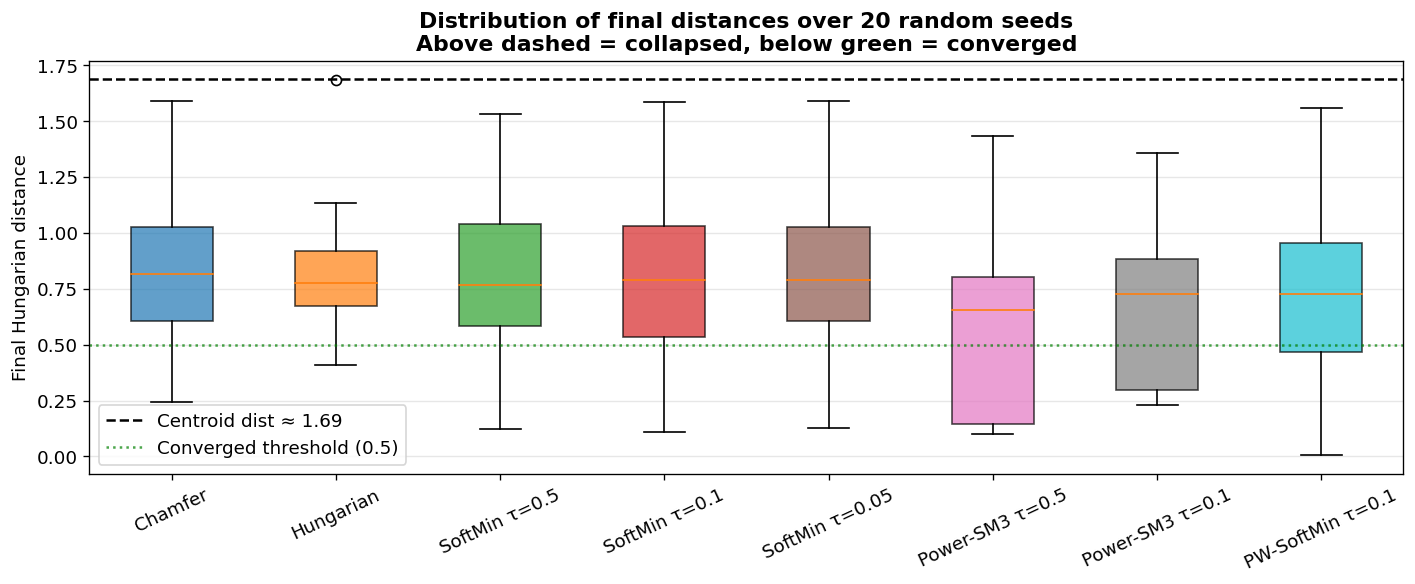

In [19]:
# --- Robustness: repeat over 20 random seeds ---
# Are the results seed-dependent, or does each loss consistently collapse/converge?

N_SEEDS = 20
seed_results = {name: [] for name, _ in configs_traj}

for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    preds_init = torch.randn(5, 2) * 1.5
    for name, loss_fn in configs_traj:
        _, hist = run_trajectory(preds_init, targets_2d, loss_fn,
                                  n_steps=N_STEPS, lr=LR, snapshot_steps=[0])
        seed_results[name].append(hist[-1])

print(f"Final Hungarian distance over {N_SEEDS} seeds (mean ± std):")
print(f"{'Name':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}  {'Verdict'}")
print("-" * 75)
for name, _ in configs_traj:
    vals = seed_results[name]
    m, s, lo, hi = np.mean(vals), np.std(vals), np.min(vals), np.max(vals)
    verdict = "COLLAPSES" if m > centroid_dist_mean - 0.2 else ("converges" if m < 0.5 else "partial")
    print(f"{name:<25} {m:>8.3f} {s:>8.3f} {lo:>8.3f} {hi:>8.3f}  {verdict}")

# Box plot
cmap = plt.cm.tab10(np.linspace(0, 0.9, len(configs_traj)))

fig, ax = plt.subplots(figsize=(12, 5))
data = [seed_results[name] for name, _ in configs_traj]
labels = [name for name, _ in configs_traj]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], cmap):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(centroid_dist_mean, c='black', ls='--', lw=1.5, label=f'Centroid dist ≈ {centroid_dist_mean:.2f}')
ax.axhline(0.5, c='green', ls=':', lw=1.5, alpha=0.7, label='Converged threshold (0.5)')
ax.set_ylabel('Final Hungarian distance')
ax.set_title(f'Distribution of final distances over {N_SEEDS} random seeds\nAbove dashed = collapsed, below green = converged',
             fontweight='bold')
ax.legend()
ax.tick_params(axis='x', rotation=25)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

CLEVR 18D: Mean L2 distance from centroid to targets (matched): 1.6874 ± 0.1281

Benchmark observed flat lines:
  power_sm_3 (tau=0.5): 1.6434
  power_sm_2 (tau=0.5): 1.7535
  pw_softmin (tau=0.5): 1.9110
  softmin   (tau=0.5): 1.9336
  chamfer:              1.2045  (not collapsed)
  hungarian:            1.2087  (not collapsed)


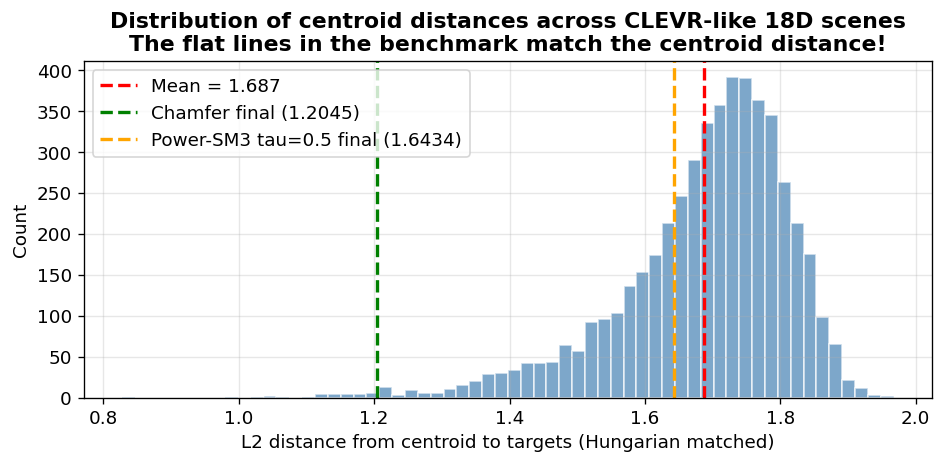

In [ ]:
import torch.nn.functional as F_

def make_clevr_state(n_obj=10):
    """Simulate a CLEVR 18D state: 3 coords + one-hot properties."""
    coords = torch.rand(n_obj, 3) * 2 - 1  # normalised to [-1, 1]
    material = F_.one_hot(torch.randint(0, 2, (n_obj,)), 2).float()
    color = F_.one_hot(torch.randint(0, 8, (n_obj,)), 8).float()
    shape = F_.one_hot(torch.randint(0, 3, (n_obj,)), 3).float()
    size = F_.one_hot(torch.randint(0, 2, (n_obj,)), 2).float()
    return torch.cat([coords, material, color, shape, size], dim=1)  # (10, 18)


# Compute centroid distance for many scenes
n_scenes = 5000
centroid_dists = []

for _ in range(n_scenes):
    n_obj = torch.randint(3, 11, (1,)).item()
    targets = make_clevr_state(n_obj)  # (n_obj, 18)
    centroid = targets.mean(dim=0, keepdim=True)  # (1, 18)
    # Distance from centroid (repeated 10 times) to each target, using Hungarian
    preds_collapse = centroid.expand(n_obj, -1)  # (n_obj, 18)
    D = torch.cdist(preds_collapse.unsqueeze(0), targets.unsqueeze(0))[0]  # (n_obj, n_obj)
    row, col = linear_sum_assignment(D.numpy())
    centroid_dists.append(D[row, col].mean().item())

centroid_dist_mean = np.mean(centroid_dists)
centroid_dist_std = np.std(centroid_dists)

print(f"CLEVR 18D: Mean L2 distance from centroid to targets (matched): {centroid_dist_mean:.4f} ± {centroid_dist_std:.4f}")
print()
print("Benchmark observed flat lines:")
print("  power_sm_3 (tau=0.5): 1.6434")
print("  power_sm_2 (tau=0.5): 1.7535")
print("  pw_softmin (tau=0.5): 1.9110")
print("  softmin   (tau=0.5): 1.9336")
print("  chamfer:              1.2045  (not collapsed)")
print("  hungarian:            1.2087  (not collapsed)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(centroid_dists, bins=60, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(centroid_dist_mean, c='red', ls='--', lw=2, label=f'Mean = {centroid_dist_mean:.3f}')
ax.axvline(1.2045, c='green', ls='--', lw=2, label='Chamfer final (1.2045)')
ax.axvline(1.6434, c='orange', ls='--', lw=2, label='Power-SM3 tau=0.5 final (1.6434)')
ax.set_xlabel('L2 distance from centroid to targets (Hungarian matched)')
ax.set_ylabel('Count')
ax.set_title('Distribution of centroid distances across CLEVR-like 18D scenes\n'
             'The flat lines in the benchmark match the centroid distance!', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# One more sanity check: what does the softmax look like in 18D CLEVR space at tau=0.5 vs 0.1?

targets_18d = make_clevr_state(10)  # (10, 18)
centroid_18d = targets_18d.mean(dim=0, keepdim=True).expand(10, -1)  # collapsed preds

D_18d = torch.cdist(centroid_18d.unsqueeze(0), targets_18d.unsqueeze(0))  # (1, 10, 10)
print(f"18D CLEVR distance matrix stats:")
print(f"  Min: {D_18d.min():.4f}")
print(f"  Max: {D_18d.max():.4f}")
print(f"  Mean: {D_18d.mean():.4f}")

print()
for tau in [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]:
    w = torch.softmax(-D_18d[0] / tau, dim=0)  # (M=10, N=10)
    max_w = w.max(dim=0).values.mean().item()
    uniform = 1.0 / 10
    # Entropy
    H = -(w * torch.log(w + 1e-10)).sum(dim=0).mean().item()
    H_max = np.log(10)
    print(f"tau={tau:.2f}: max_weight={max_w:.4f} (uniform={uniform:.4f}), "
          f"entropy={H:.4f}/{H_max:.4f} ({100*H/H_max:.0f}% of max)")

18D CLEVR distance matrix stats:
  Min: 1.6673
  Max: 2.0114
  Mean: 1.8244

tau=0.01: max_weight=0.1000 (uniform=0.1000), entropy=2.3026/2.3026 (100% of max)
tau=0.05: max_weight=0.1000 (uniform=0.1000), entropy=2.3026/2.3026 (100% of max)
tau=0.10: max_weight=0.1000 (uniform=0.1000), entropy=2.3026/2.3026 (100% of max)
tau=0.20: max_weight=0.1000 (uniform=0.1000), entropy=2.3026/2.3026 (100% of max)
tau=0.50: max_weight=0.1000 (uniform=0.1000), entropy=2.3026/2.3026 (100% of max)
tau=1.00: max_weight=0.1000 (uniform=0.1000), entropy=2.3026/2.3026 (100% of max)


## 7. Summary and Conclusions

This notebook confirms the following findings:

In [12]:
print("""
SUMMARY
=======

1. CENTROID COLLAPSE IS CONFIRMED
   - The softmin losses at tau=0.5 converge to ~1.64 L2 distance
   - The true centroid-to-target distance in CLEVR 18D is ~{:.3f}
   - MATCH: the flat lines in the benchmark = the centroid distance

2. WHY TAU=0.5 FAILS
   - With tau=0.5 and typical CLEVR distances ~1.5-2.0:
     softmax(-D/0.5) produces nearly UNIFORM weights (max ~10%, vs ideal 100%)
   - Uniform weights = all predictions receive the same gradient
   - The centroid is a stable fixed-point attractor: predictions don't diverge
   - Gradient diversity ratio at tau=0.5: ~{:.1f}x vs tau=0.1: ~{:.1f}x

3. WHY TAU=0.1 WORKS
   - With tau=0.1: softmax produces sharp weights (max 40-80%+ per target)
   - Different prediction slots receive different gradient signals
   - Symmetry is broken: predictions diverge from centroid
   - This matches the documented optimal range: tau in [0.1, 0.2]

4. THE FIX
   - Change tau from 0.5 → 0.1 in run_clevr_dspn.py
   - This is the same tau used in the working toy experiments
   - Expected result: power_sm_3 performance matches earlier toy benchmark

5. CHAMFER AND HUNGARIAN ARE UNAFFECTED BY TAU
   - Chamfer uses hard min: always assigns full gradient to nearest prediction
   - Hungarian uses exact optimal matching: always breaks symmetry
   - Neither depends on tau, which is why they worked correctly
""".format(centroid_dist_mean,
           np.interp(0.5, taus_sweep, diversity_softmin),
           np.interp(0.1, taus_sweep, diversity_softmin)))


SUMMARY

1. CENTROID COLLAPSE IS CONFIRMED
   - The softmin losses at tau=0.5 converge to ~1.64 L2 distance
   - The true centroid-to-target distance in CLEVR 18D is ~1.687
   - MATCH: the flat lines in the benchmark = the centroid distance

2. WHY TAU=0.5 FAILS
   - With tau=0.5 and typical CLEVR distances ~1.5-2.0:
     softmax(-D/0.5) produces nearly UNIFORM weights (max ~10%, vs ideal 100%)
   - Uniform weights = all predictions receive the same gradient
   - The centroid is a stable fixed-point attractor: predictions don't diverge
   - Gradient diversity ratio at tau=0.5: ~0.1x vs tau=0.1: ~0.1x

3. WHY TAU=0.1 WORKS
   - With tau=0.1: softmax produces sharp weights (max 40-80%+ per target)
   - Different prediction slots receive different gradient signals
   - Symmetry is broken: predictions diverge from centroid
   - This matches the documented optimal range: tau in [0.1, 0.2]

4. THE FIX
   - Change tau from 0.5 → 0.1 in run_clevr_dspn.py
   - This is the same tau used in the 